In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
from linearmodels.panel import compare

In [2]:
df = pd.read_csv('../data/processed_data/master_dataset_final.csv')
display(df.head())
sns.set_theme(style="whitegrid")

,geo,nace_r2,time_period,gva_millions,hours_thousands,labor_productivity,AIIE_Index
0,AT,A,2008,4350.4,527584.0,8.245891,0.262195
1,AT,A,2009,4044.6,504012.0,8.024809,0.262195
2,AT,A,2010,3801.7,487378.0,7.800311,0.262195
3,AT,A,2011,4385.3,501351.0,8.746966,0.262195
4,AT,A,2012,4096.2,452804.0,9.046298,0.262195


In [3]:
# numerical variables
num_vars = ['labor_productivity', 'AIIE_Index', 'gva_millions', 'hours_thousands']

# descriptive statistics
summary_stats = df[num_vars].describe().T.round(2)

# skewness
summary_stats['skewness'] = df[num_vars].skew().round(2)

print("Table 1: Descriptive Statistics")
display(summary_stats)


Table 1: Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max,skewness
labor_productivity,10589.0,51.67,101.25,0.25,12.84,26.02,46.19,1545.70,5.72
AIIE_Index,10589.0,0.50,0.13,0.19,0.40,0.50,0.62,0.75,-0.27
gva_millions,10589.0,50710.06,165001.14,3.60,1512.90,5350.90,23330.00,2048518.60,6.13
hours_thousands,10589.0,1490345.37,4742070.67,532.00,61885.00,229401.00,729244.00,56544517.00,6.26


C:\Users\allen\AppData\Local\Temp\ipykernel_15524\1626248139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=industry_exposure.index, y=industry_exposure.values, palette="viridis")


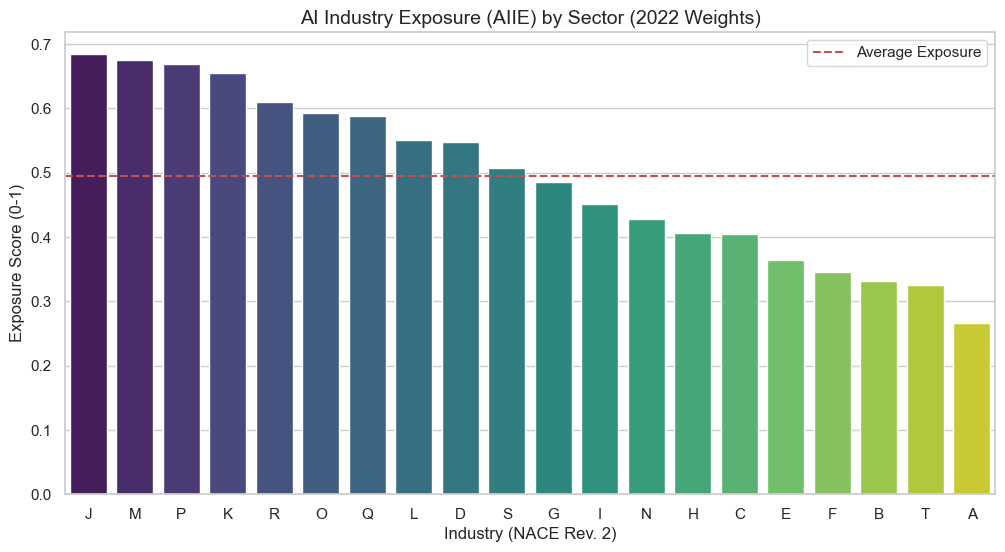

Top 3 Most Exposed Industries:
nace_r2
J    0.684241
M    0.675580
P    0.668771
Name: AIIE_Index, dtype: float64

Bottom 3 Least Exposed Industries:
nace_r2
B    0.331841
T    0.325188
A    0.266240
Name: AIIE_Index, dtype: float64


In [4]:
# average exposure per industry 
industry_exposure = df.groupby('nace_r2')['AIIE_Index'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=industry_exposure.index, y=industry_exposure.values, palette="viridis")

plt.title('AI Industry Exposure (AIIE) by Sector (2022 Weights)', fontsize=14)
plt.xlabel('Industry (NACE Rev. 2)', fontsize=12)
plt.ylabel('Exposure Score (0-1)', fontsize=12)
plt.axhline(y=industry_exposure.mean(), color='r', linestyle='--', label='Average Exposure')
plt.legend()
plt.show()

print("Top 3 Most Exposed Industries:")
print(industry_exposure.head(3))
print("\nBottom 3 Least Exposed Industries:")
print(industry_exposure.tail(3))

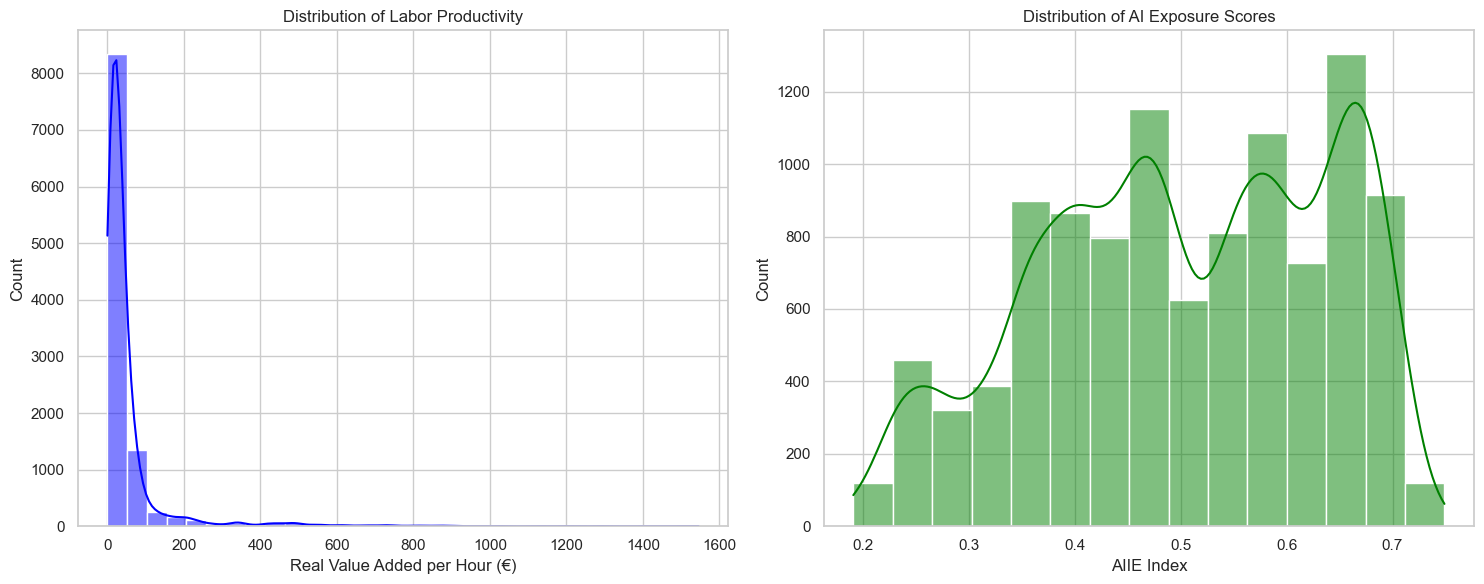

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribution of Productivity
sns.histplot(df['labor_productivity'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Labor Productivity')
axes[0].set_xlabel('Real Value Added per Hour (€)')

# Distribution of AI Exposure
sns.histplot(df['AIIE_Index'], bins=15, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of AI Exposure Scores')
axes[1].set_xlabel('AIIE Index')

plt.tight_layout()
plt.show()

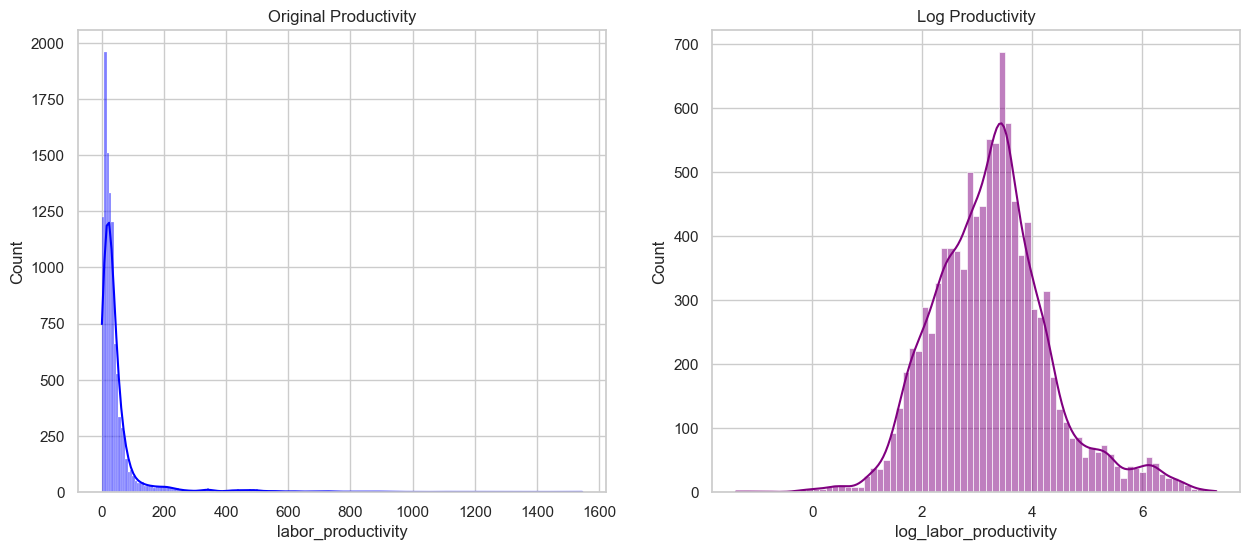

In [6]:
# Log of Productivity
df['log_labor_productivity'] = np.log(df['labor_productivity'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# original plot
sns.histplot(df['labor_productivity'], color='blue', ax=axes[0], kde=True)
axes[0].set_title('Original Productivity')

# Log-Transformed plot
sns.histplot(df['log_labor_productivity'], color='purple', ax=axes[1], kde=True)
axes[1].set_title('Log Productivity')

plt.show()

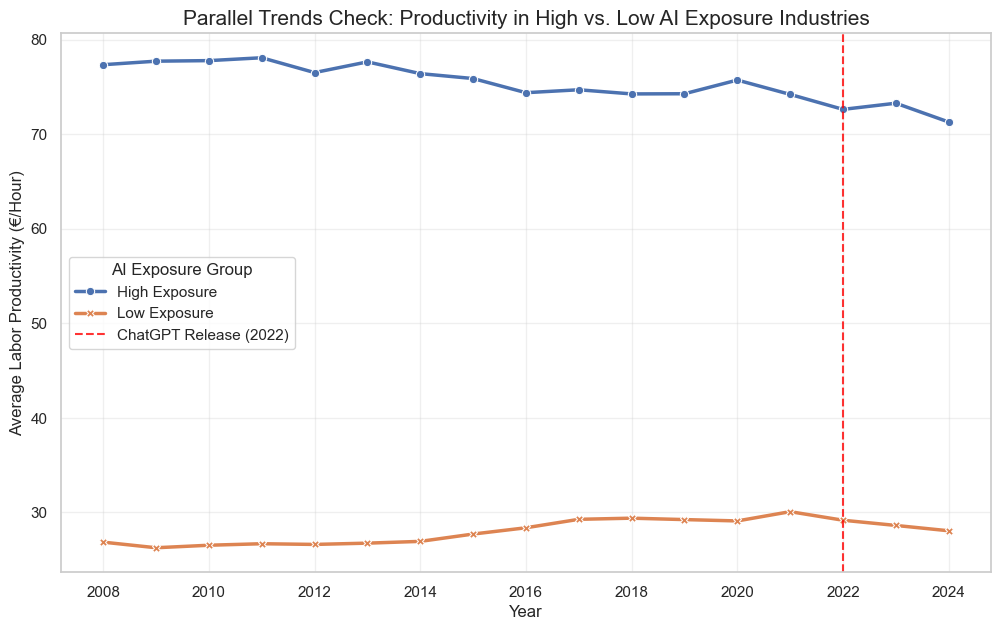

In [7]:
# Define "High" vs "Low" exposure groups based on the Median
median_exposure = df['AIIE_Index'].median()
df['Group'] = np.where(df['AIIE_Index'] > median_exposure, 'High Exposure', 'Low Exposure')

# Aggregate data by Year and Group
trend_data = df.groupby(['time_period', 'Group'])['labor_productivity'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=trend_data, x='time_period', y='labor_productivity', hue='Group', 
             style='Group', markers=True, dashes=False, linewidth=2.5)

# chat gpt release
plt.axvline(x=2022, color='red', linestyle='--', alpha=0.8, label='ChatGPT Release (2022)')

plt.title('Parallel Trends Check: Productivity in High vs. Low AI Exposure Industries', fontsize=15)
plt.ylabel('Average Labor Productivity (€/Hour)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='AI Exposure Group')
plt.grid(True, alpha=0.3)

# Save figure
plt.savefig('../figures/parallel_trends_plot.png')
plt.show()

In [8]:
df_reg = df.set_index(['nace_r2', 'geo', 'time_period'])

# Y = Log Productivity 
# X = Interaction Term (AI_Score * Post_2022_Dummy)

# Create the "Post 2022" Dummy Variable
df['Post_ChatGPT'] = (df['time_period'] >= 2023).astype(int)

# Create the Interaction Term 
df['Treat_x_Post'] = df['AIIE_Index'] * df['Post_ChatGPT']

# Country + Industry
df['entity_id'] = df['geo'] + '_' + df['nace_r2']
reg_data = df.set_index(['entity_id', 'time_period'])

# Fixed Effects Model
mod = PanelOLS(reg_data['log_labor_productivity'], 
               reg_data[['Treat_x_Post']], 
               entity_effects=True, 
               time_effects=True)

res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res)

                            PanelOLS Estimation Summary                             
Dep. Variable:     log_labor_productivity   R-squared:                        0.0002
Estimator:                       PanelOLS   R-squared (Between):             -0.0015
No. Observations:                   10589   R-squared (Within):              -0.0127
Date:                    Wed, Feb 18 2026   R-squared (Overall):             -0.0016
Time:                            16:31:22   Log-likelihood                    5618.6
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      2.0422
Entities:                             625   P-value                           0.1530
Avg Obs:                           16.942   Distribution:                  F(1,9947)
Min Obs:                           16.000                                           
Max Obs:                           17.000   F-statistic (robust):

In [9]:
# pruductivity decomposition GVA/hours
# creating log GVA and log hours
df['log_gva'] = np.log(df['gva_millions'])
df['log_hours'] = np.log(df['hours_thousands'])

reg_data = df.set_index(['entity_id', 'time_period'])

# --- Model 2: The Output Effect (GVA) ---
print("\n--- Model 2: Impact on Real Output (GVA) ---")
mod_gva = PanelOLS(reg_data['log_gva'], 
                   reg_data[['Treat_x_Post']], 
                   entity_effects=True, 
                   time_effects=True)
res_gva = mod_gva.fit(cov_type='clustered', cluster_entity=True)
print(res_gva)

# --- Model 3: The Labor Saving Effect (Hours) ---
print("\n--- Model 3: Impact on Labor Inputs (Hours Worked) ---")
mod_hours = PanelOLS(reg_data['log_hours'], 
                     reg_data[['Treat_x_Post']], 
                     entity_effects=True, 
                     time_effects=True)
res_hours = mod_hours.fit(cov_type='clustered', cluster_entity=True)
print(res_hours)


--- Model 2: Impact on Real Output (GVA) ---
                          PanelOLS Estimation Summary                           
Dep. Variable:                log_gva   R-squared:                        0.0179
Estimator:                   PanelOLS   R-squared (Between):              0.0063
No. Observations:               10589   R-squared (Within):               0.0518
Date:                Wed, Feb 18 2026   R-squared (Overall):              0.0063
Time:                        16:31:25   Log-likelihood                    4470.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      181.62
Entities:                         625   P-value                           0.0000
Avg Obs:                       16.942   Distribution:                  F(1,9947)
Min Obs:                       16.000                                           
Max Obs:                       17.000   F-statistic (robust):  

In [10]:

models = {
    'Model 1: Productivity': res,       
    'Model 2: Output (GVA)': res_gva,   
    'Model 3: Labor (Hours)': res_hours 
}

# CORRECTED LINE: Removed 'precision=4'
final_table = compare(models, stars=True)

print(final_table)

# Save to file
with open('../tables/final_regression_results.txt', 'w') as f:
    f.write(str(final_table))
    


                                        Model Comparison                                       
                             Model 1: Productivity Model 2: Output (GVA) Model 3: Labor (Hours)
-----------------------------------------------------------------------------------------------
Dep. Variable               log_labor_productivity               log_gva              log_hours
Estimator                                 PanelOLS              PanelOLS               PanelOLS
No. Observations                             10589                 10589                  10589
Cov. Est.                                Clustered             Clustered              Clustered
R-squared                                   0.0002                0.0179                 0.0381
R-Squared (Within)                         -0.0127                0.0518                -0.0785
R-Squared (Between)                        -0.0015                0.0063                 0.0050
R-Squared (Overall)                     

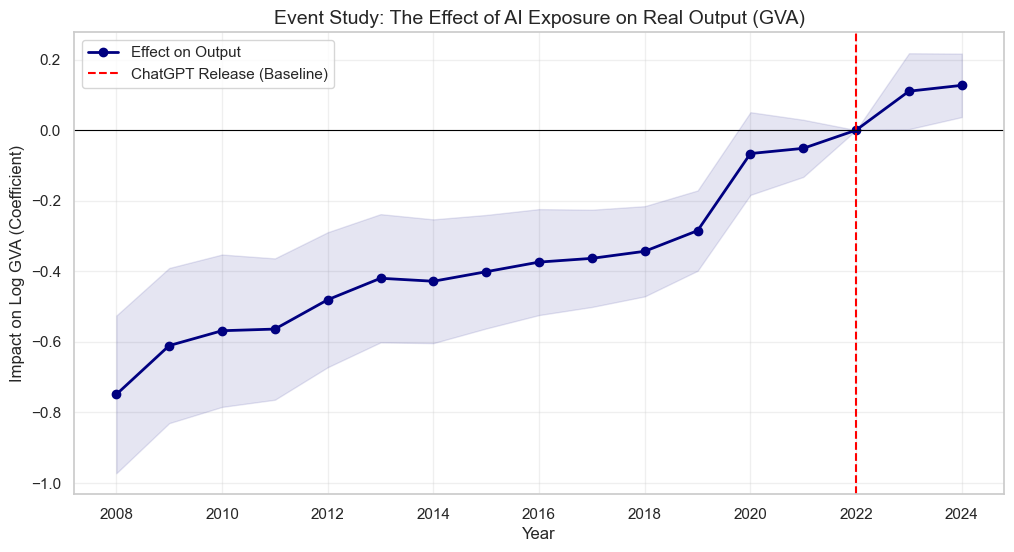

In [11]:

# We interact the AI Index with a dummy for each year.
# We DROP one year (2022) to serve as the baseline (Reference Year = 0).

years = sorted(df['time_period'].unique())
reference_year = 2022

event_study_vars = []
for year in years:
    if year != reference_year:
        col_name = f'Treat_x_{year}'
        # Create the interaction
        df[col_name] = df['AIIE_Index'] * (df['time_period'] == year).astype(int)
        event_study_vars.append(col_name)

# Run the Regression
# We use all the yearly interaction terms instead of just one "Post" dummy
reg_data = df.set_index(['entity_id', 'time_period'])
mod_event = PanelOLS(reg_data['log_gva'],  # Dependent Variable: Output
                     reg_data[event_study_vars], 
                     entity_effects=True, 
                     time_effects=True)
res_event = mod_event.fit(cov_type='clustered', cluster_entity=True)

# We get the coefficients and the 95% Confidence Intervals
coefs = res_event.params
errors = res_event.std_errors
# Calculate 95% CI (1.96 * Standard Error)
lower_ci = coefs - 1.96 * errors
upper_ci = coefs + 1.96 * errors

plot_df = pd.DataFrame({
    'Year': [int(x.split('_')[-1]) for x in event_study_vars],
    'Coefficient': coefs,
    'Lower_CI': lower_ci,
    'Upper_CI': upper_ci
})

# Add the reference year (2022) back manually with 0 effect (for the plot)
plot_df.loc[len(plot_df)] = [2022, 0, 0, 0]
plot_df = plot_df.sort_values('Year')

plt.figure(figsize=(12, 6))

# Plot the coefficients 
plt.plot(plot_df['Year'], plot_df['Coefficient'], marker='o', color='navy', linewidth=2, label='Effect on Output')

# Add the Confidence Intervals
plt.fill_between(plot_df['Year'], plot_df['Lower_CI'], plot_df['Upper_CI'], color='navy', alpha=0.1)

# Add reference lines
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)  # Zero line
plt.axvline(2022, color='red', linestyle='--', label='ChatGPT Release (Baseline)') # Event line

# Formatting
plt.title('Event Study: The Effect of AI Exposure on Real Output (GVA)', fontsize=14)
plt.ylabel('Impact on Log GVA (Coefficient)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [12]:
# Robustness Check

# Creating a Linear Time Trend Variable (0, 1, 2, 3...)
df['trend'] = df['time_period'] - df['time_period'].min()

reg_data = df.set_index(['entity_id', 'time_period'])

# Define the Model with Interaction Trends
# We interact 'nace_r2' (Industry) with 'trend'
# This allows every industry to have its own unique growth slope
formula = 'log_gva ~ Treat_x_Post + EntityEffects + TimeEffects + nace_r2:trend'

# Create the specific trend column for the High vs Low groups
df['Group_Trend'] = df['AIIE_Index'] * df['trend']

reg_data = df.set_index(['entity_id', 'time_period'])

print("--- Robustness Check: Controlling for Pre-Existing Trends ---")
mod_robust = PanelOLS(reg_data['log_gva'], 
                      reg_data[['Treat_x_Post', 'Group_Trend']], 
                      entity_effects=True, 
                      time_effects=True)

res_robust = mod_robust.fit(cov_type='clustered', cluster_entity=True)
print(res_robust)

--- Robustness Check: Controlling for Pre-Existing Trends ---
                          PanelOLS Estimation Summary                           
Dep. Variable:                log_gva   R-squared:                        0.0424
Estimator:                   PanelOLS   R-squared (Between):              0.0410
No. Observations:               10589   R-squared (Within):               0.1201
Date:                Wed, Feb 18 2026   R-squared (Overall):              0.0410
Time:                        16:31:34   Log-likelihood                    4604.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      220.46
Entities:                         625   P-value                           0.0000
Avg Obs:                       16.942   Distribution:                  F(2,9946)
Min Obs:                       16.000                                           
Max Obs:                       17.000   F-stati